# Sampel 3, Area dan Batasan Motif

In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import skan
from utils import *

In [37]:
border = cv2.imread('sampel-3_batasan.PNG')
border_binary = binarize(border)
leaf_area = cv2.imread('sampel-3_area-daun.PNG')
leaf_area_binary = binarize(leaf_area) - border_binary
semicircle_area = cv2.imread('sampel-3_area-separuh-lingkaran.PNG')
semicircle_area_binary = binarize(semicircle_area) - border_binary
square_area = cv2.imread('sampel-3_area-kotak.PNG')
square_area_binary = binarize(square_area) - border_binary


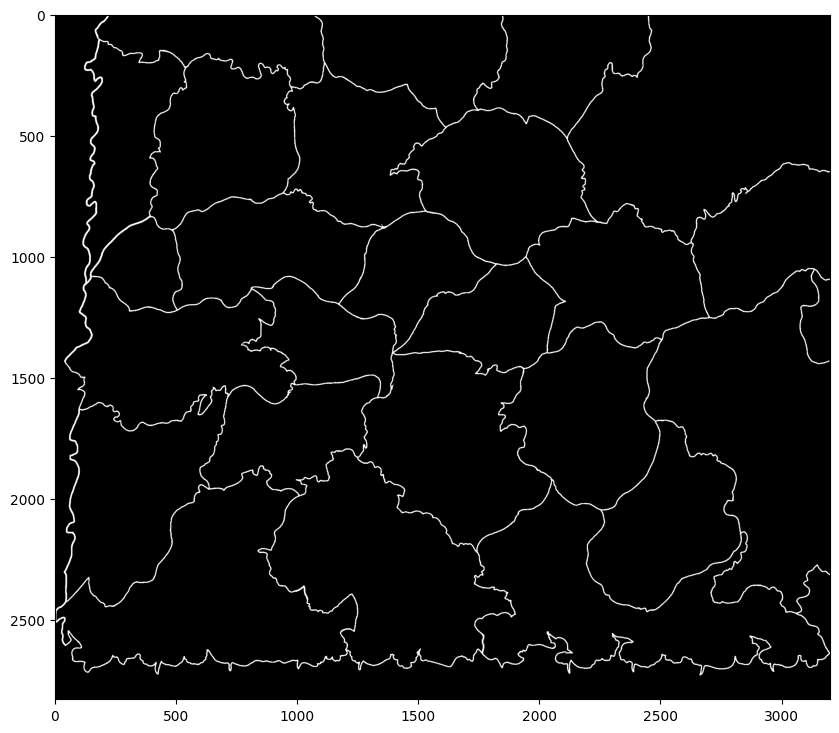

In [38]:
plt.figure(figsize=(10, 10))
plt.imshow(border_binary, cmap='grey')

## Tutupan Area

In [39]:
leaf_area_occupancy = getAreaOccupancy(leaf_area_binary)
semicircle_area_occupancy = getAreaOccupancy(semicircle_area_binary)
square_area_occupancy = getAreaOccupancy(square_area_binary)

print(f"Leaf       Area Occupancy : {leaf_area_occupancy*100:.2f}%")
print(f"Semicircle Area Occupancy : {semicircle_area_occupancy*100:.2f}%")
print(f"Square     Area Occupancy : {square_area_occupancy*100:.2f}%")

Leaf       Area Occupancy : 26.18%
Semicircle Area Occupancy : 44.49%
Square     Area Occupancy : 17.18%


In [40]:
total_area_binary = leaf_area_binary + semicircle_area_binary + square_area_binary

num_area, area_map, area_stats, area_centroids = cv2.connectedComponentsWithStats(total_area_binary)

num_area

27

DATA SUMMARY of [Area Volumes]:
Num     : 26
Mean    : 305560.8462
SD      : 157242.0045
SD rel  : 51.46%
Median  : 278431.0000
MAD     : 68149.5000
MAD rel : 24.48%
Min     : 25427.0000
Max     : 715103.0000



<Axes: ylabel='Count'>

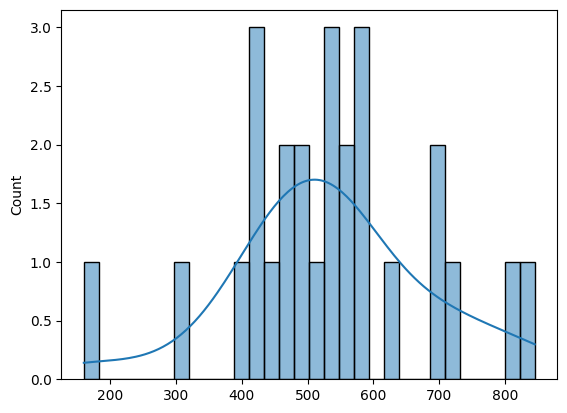

In [41]:
area_volume = area_stats[1:, cv2.CC_STAT_AREA]

summarizeData(area_volume,"Area Volumes")

sns.histplot(np.sqrt(area_volume), kde=True, bins=30)

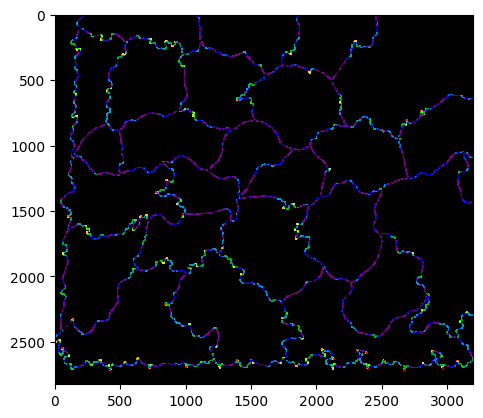

In [42]:
border_skeleton_image, border_skan = skeletonize(border_binary, 10)

curvature_map = mapBranchCurvature(border_skeleton_image, border_skan, 21)
curvature_map_test = curvature_map.copy()
curvature_map_test[np.isnan(curvature_map)] = 0
curvature_map_test = cv2.dilate(curvature_map_test, np.ones((3, 3), np.uint8), iterations=5)

plt.imshow(curvature_map_test / np.pi * 180, cmap='nipy_spectral', vmin=0, vmax=180, interpolation='nearest')

DATA SUMMARY of [Curvature]:
Num     : 35337
Mean    : 31.0088
SD      : 30.0386
SD rel  : 96.87%
Median  : 21.6453
MAD     : 14.3541
MAD rel : 66.32%
Min     : 0.0000
Max     : 179.8352



{'num': 35337,
 'mean': 31.008752594006545,
 'sd': 30.038622476565397,
 'median': 21.645324280569465,
 'mad': 14.354136946680159,
 'min': 0.0,
 'max': 179.83521352787912}

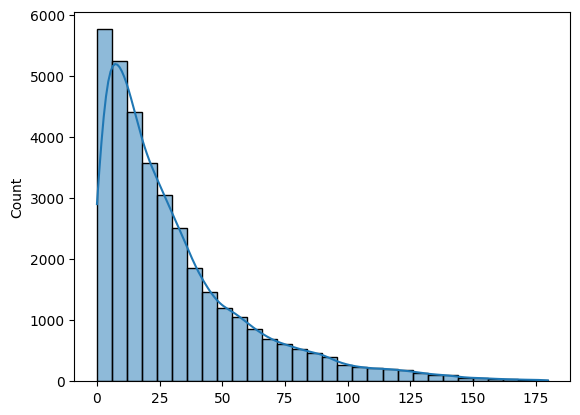

In [43]:
sns.histplot(curvature_map[~np.isnan(curvature_map)] / np.pi * 180, kde=True, bins=30)
summarizeData(curvature_map[~np.isnan(curvature_map)] / np.pi * 180, "Curvature")